# Multi-seed diagnostic plots (Figures 6-12)

Reuses `tools/plot_multiseed_diagnostics.py`. Each figure is drawn inline AND saved as PDF+PNG into `res/figures_pdf/multiseed_diagnostics/`.

In [1]:
import sys, os
from pathlib import Path
REPO = Path.cwd()
while not (REPO / 'tools' / 'plot_multiseed_diagnostics.py').exists():
    if REPO.parent == REPO: raise RuntimeError('repo root not found')
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
os.chdir(REPO)
import tools.plot_multiseed_diagnostics as M
from importlib import reload; reload(M)
%matplotlib inline
print('out dir:', M.OUT_DIR)
print('runs root:', M.find_runs_root())

out dir: /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/multiseed_diagnostics
runs root: /media/abz/Z7S/experiments_revision_offline_replay_restart_v3/runs


In [2]:
data = M.build_all(force=False)
print(f'loaded {len(data)} runs: keys={sorted(data.keys())}')
report = {'figures': []}

loaded 15 runs: keys=[(4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5)]


## Figure 6 — completion-time distribution (Full, last 200, successful only)

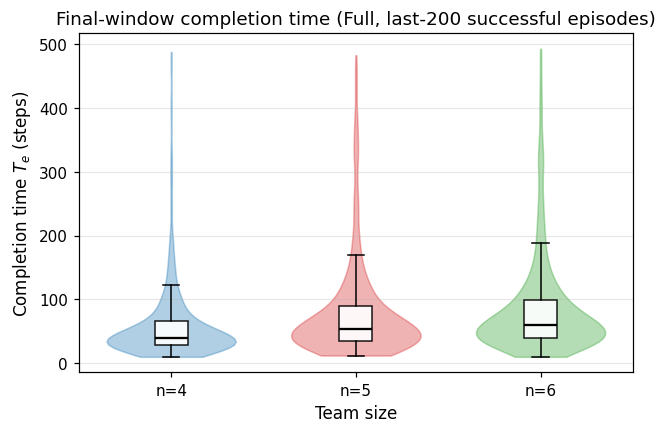

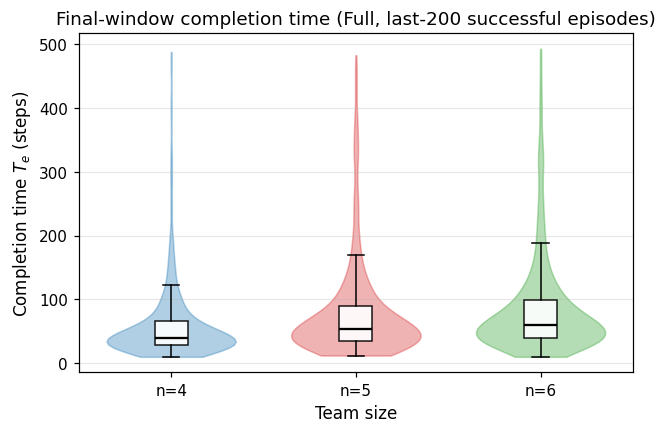

In [3]:
fig = M.fig6_completion_time(data, report); fig

## Figure 7 — cumulative completion probability $F_n(t)$

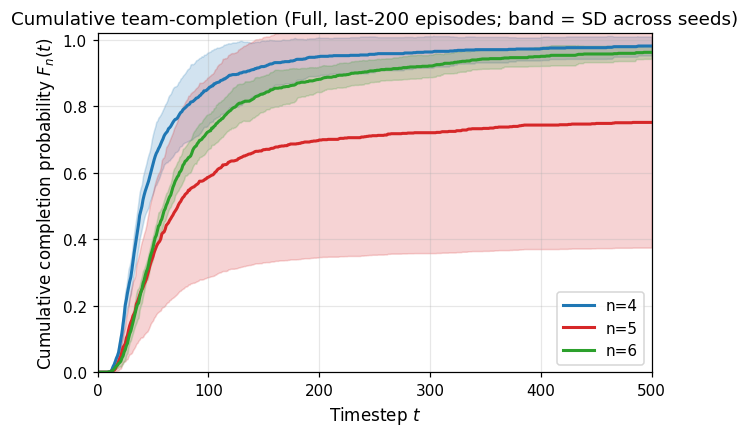

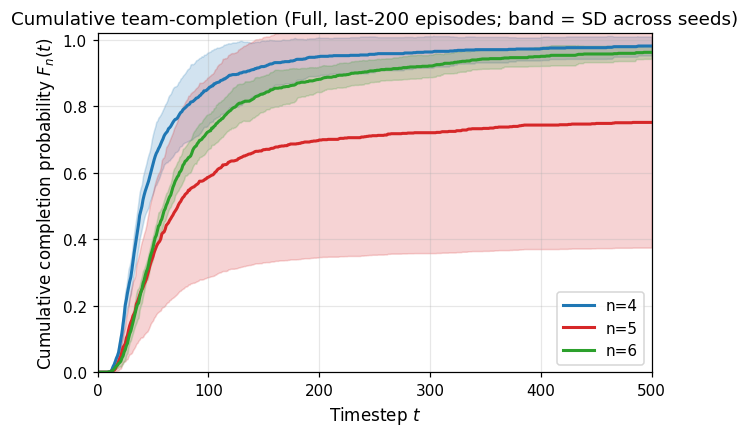

In [4]:
fig = M.fig7_cumulative(data, report); fig

## Figure 8 — mean done_count(t), early vs late

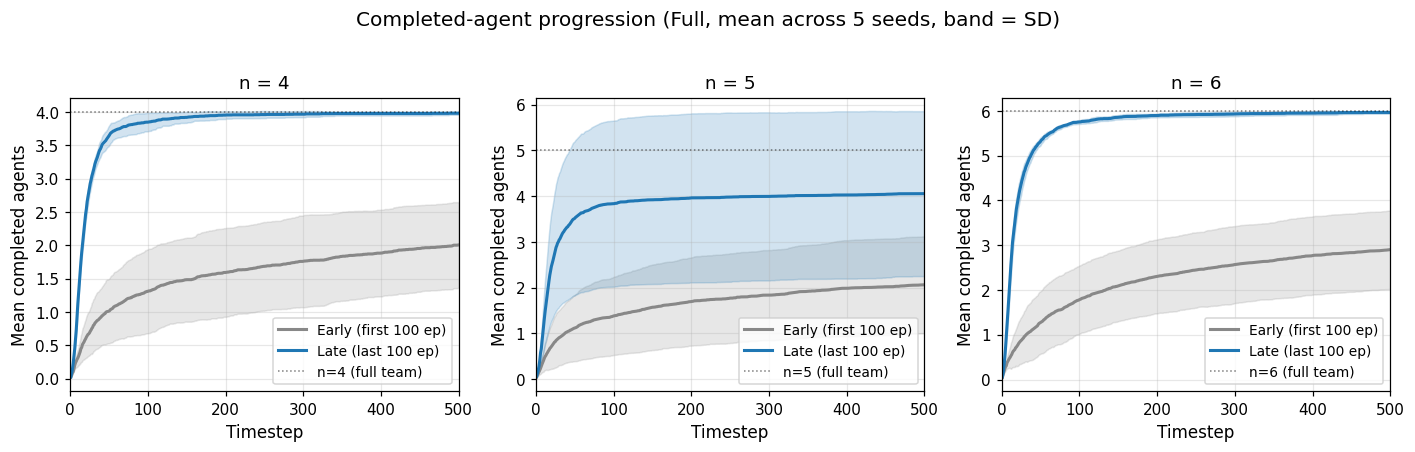

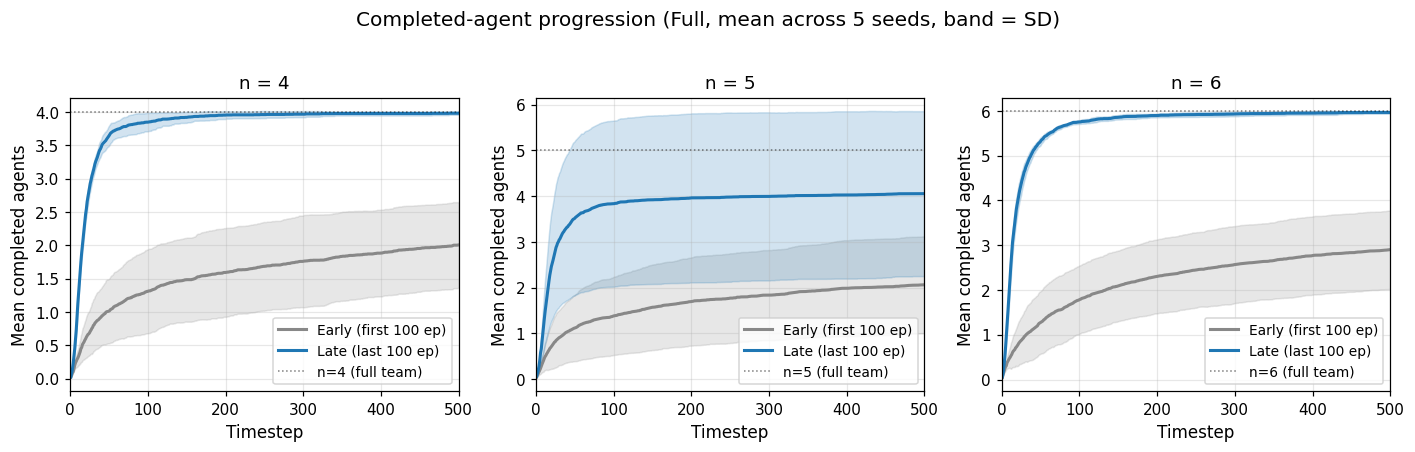

In [5]:
fig = M.fig8_done_count(data, report); fig

## Figure 9 — reward decomposition (early vs late, stacked, scaled)

**Detected reward mapping (active 8 channels, comp3 dropped because alpha=0):**
1. progressive (comp1, α=1)
2. distance-to-goal (comp2, α=1)
3. landmark coverage (comp4, α=10)
4. agent-agent collision (comp5, α=10)
5. inactive/obstacle collision (comp6, α=10)
6. linear velocity (comp7, α=1)
7. directional alignment (comp8, α=1)
8. time penalty (comp9, α=1)

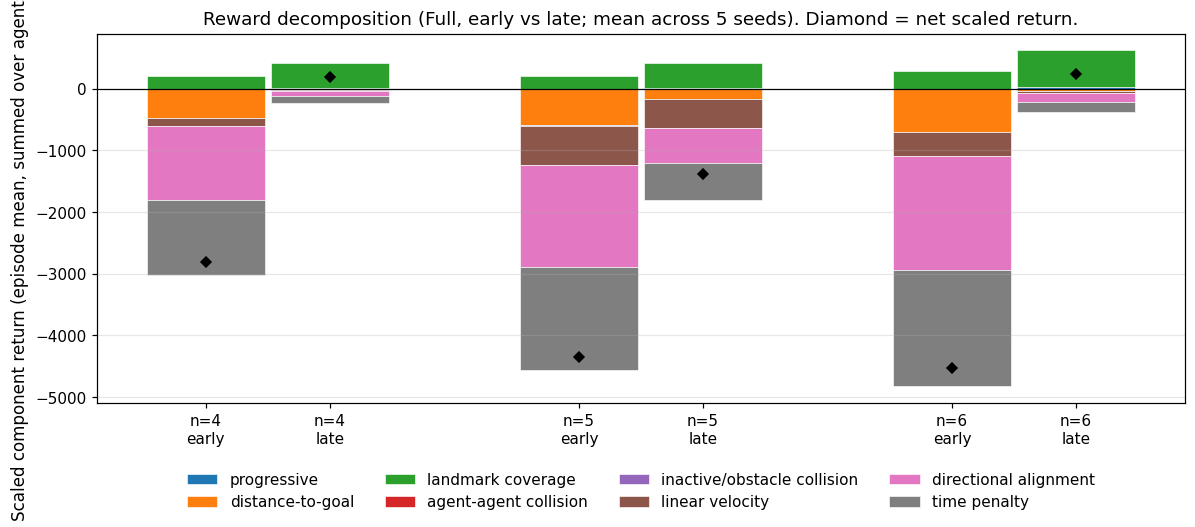

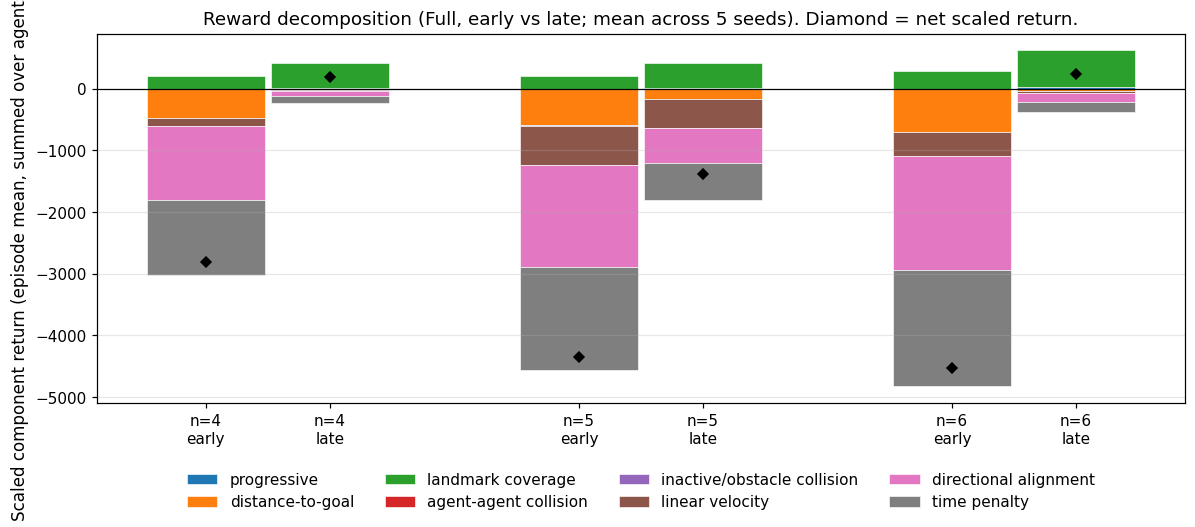

In [6]:
fig = M.fig9_reward_decomp(data, report); fig

## Figure 10 — agent-agent collision penalty trend (named comp5)

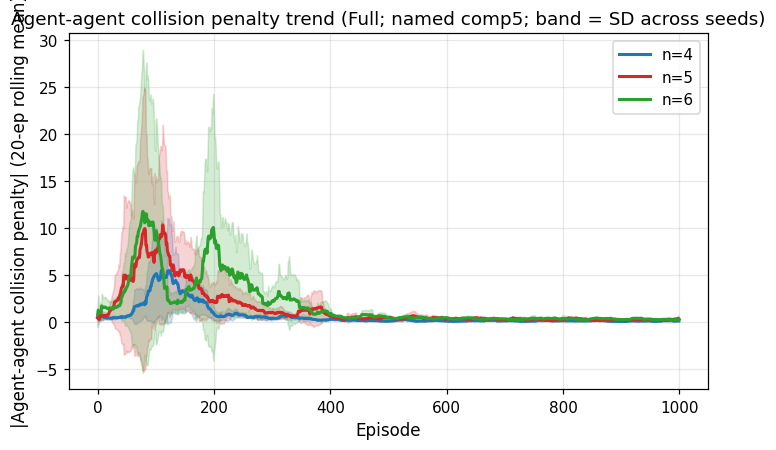

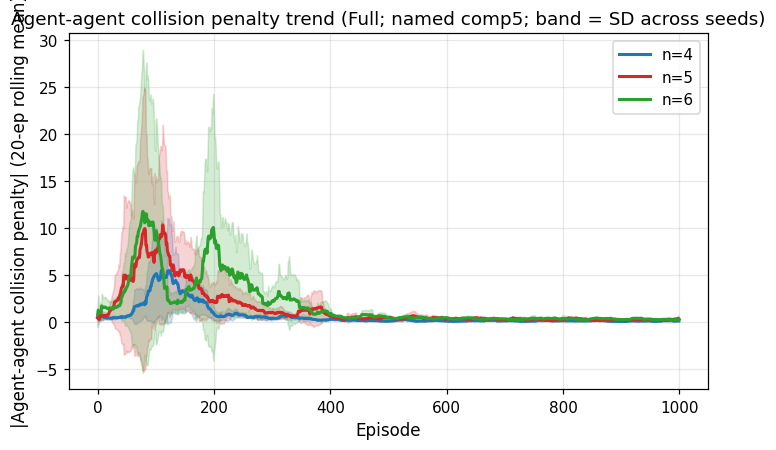

In [7]:
fig = M.fig10_collision(data, report); fig

## Figure 11 — Hungarian assignment distance D(t), early vs late

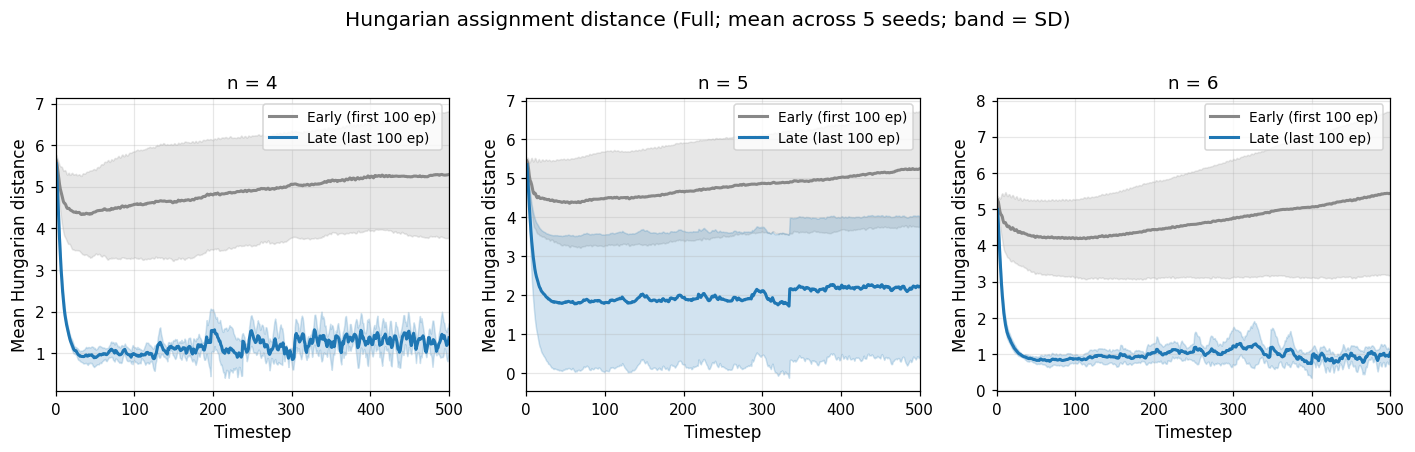

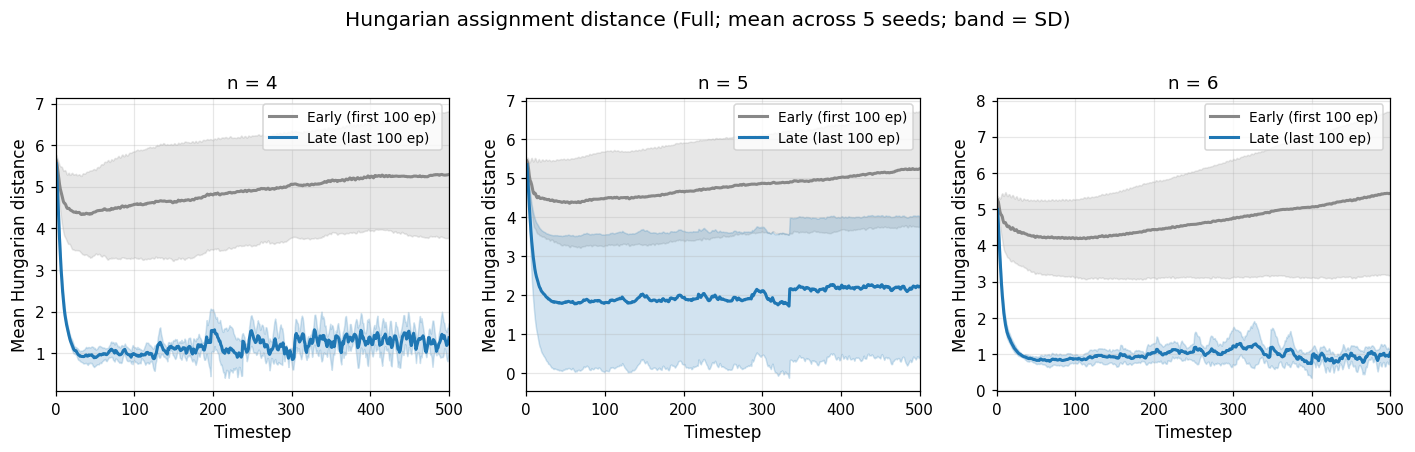

In [8]:
fig = M.fig11_hungarian(data, report); fig

## Figure 12 — velocity profiles (linear & |angular|), early vs late

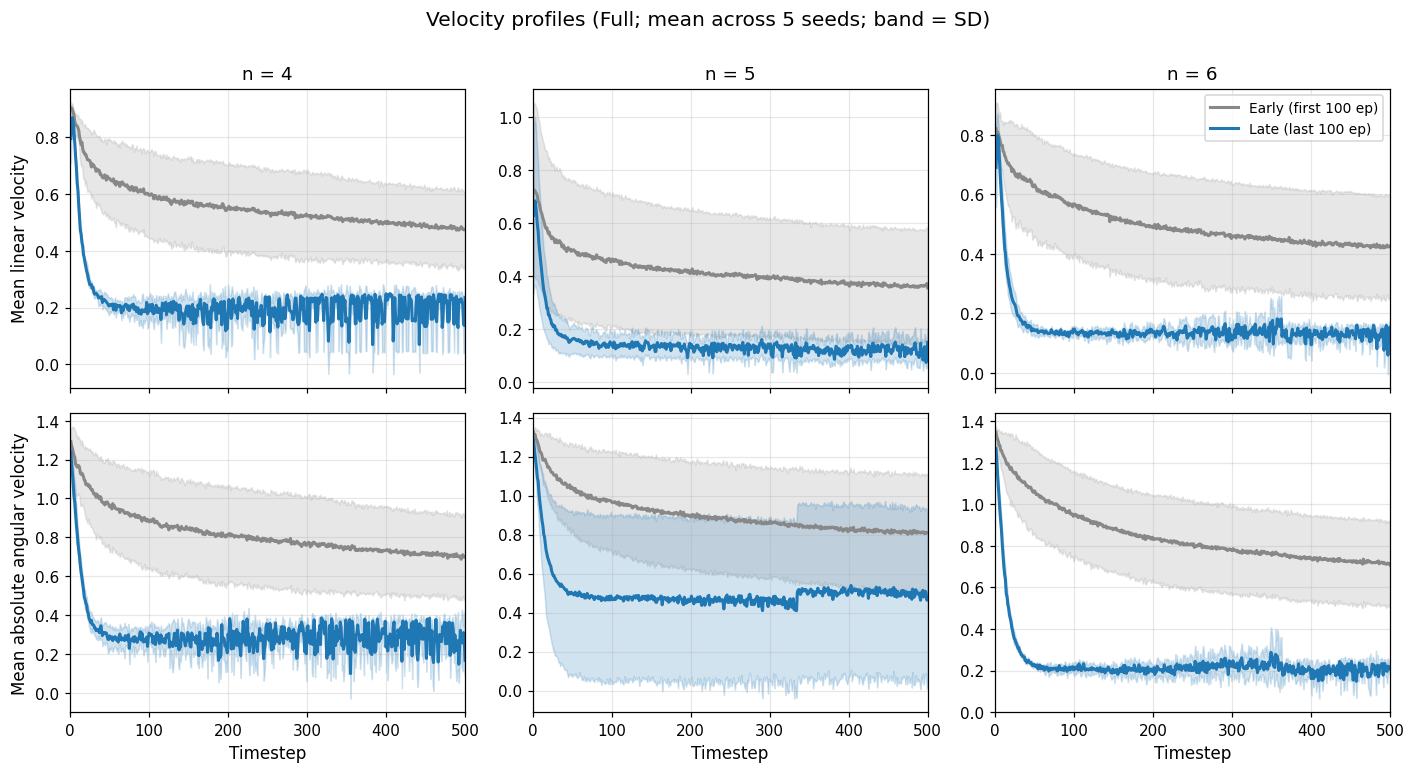

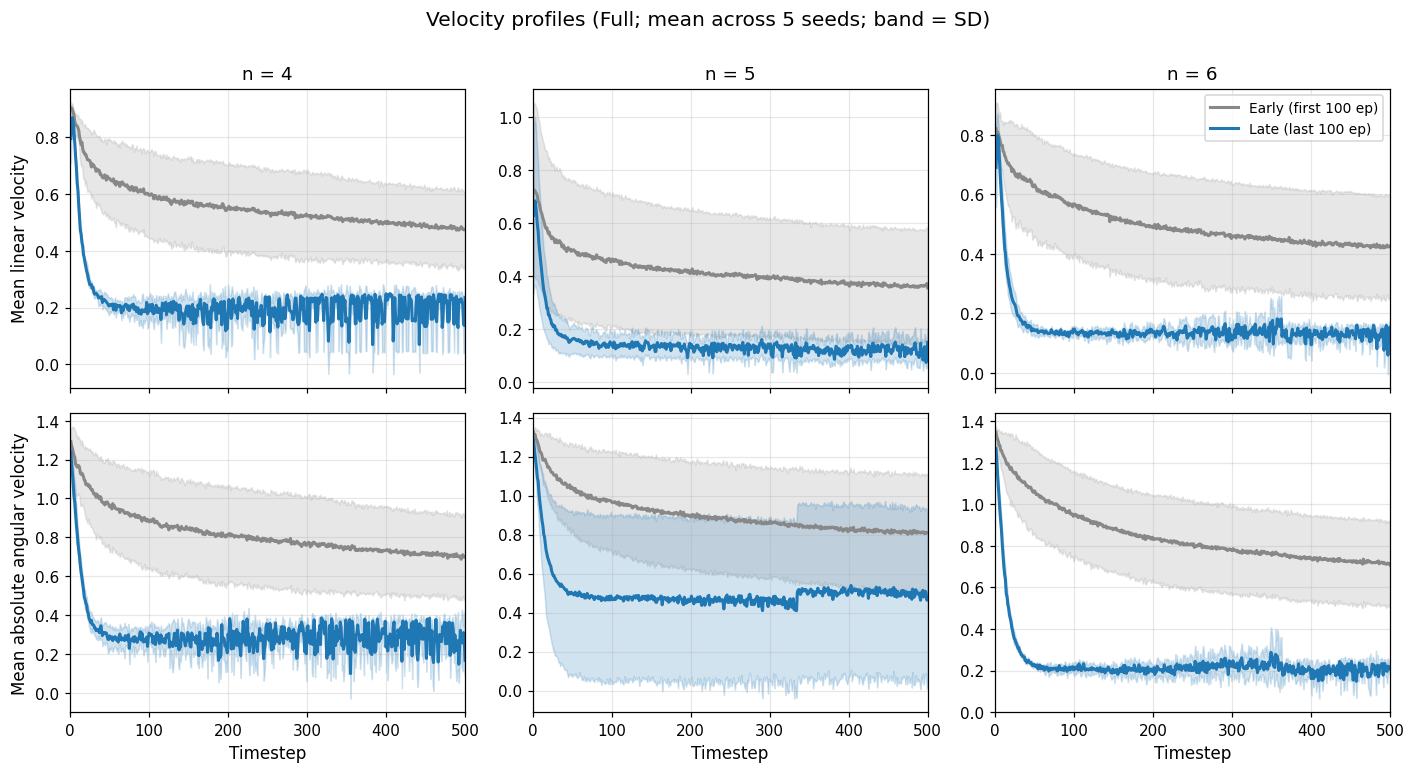

In [9]:
fig = M.fig12_velocity(data, report); fig

In [10]:
M.write_report(data, report)
print('Wrote', M.OUT_DIR / 'multiseed_diagnostic_plot_report.md')
for tag, path, status in report['figures']:
    print(f'  {tag}: {status} -> {path}')

Wrote /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/multiseed_diagnostics/multiseed_diagnostic_plot_report.md
  figure6: OK -> /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/multiseed_diagnostics/figure6_completion_time_multiseed.pdf
  figure7: OK -> /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/multiseed_diagnostics/figure7_cumulative_completion_multiseed.pdf
  figure8: OK -> /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/multiseed_diagnostics/figure8_done_count_multiseed.pdf
  figure9: OK -> /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/multiseed_diagnostics/figure9_reward_decomposition_multiseed.pdf
  figure10: OK -> /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/multiseed_diagnostics/figure10_collision_penalty_multiseed.pdf
  figure11: OK -> /home/abz/workspace/PycharmProjects/dif_driven_maddpg/res/figures_pdf/multiseed_diagnostics/figure11_hu